# Notebook 2 — Gaussian likelihood for a linear fit

In this notebook, we reformulate the linear fit problem from Notebook 1 in probabilistic terms.

The model is still:

$$
y = mx + b
$$

but instead of only finding the best-fit parameters, we now assign a likelihood value to any possible choice of parameters:

$$
\theta = (b,m).
$$

The goal is to understand how the chi-square is connected to the Gaussian log-likelihood.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use("default")

## 1. Loading the data

We use the same dataset as in Notebook 1.

Each data point contains:

- an observed value $x_i$,
- an observed value $y_i$,
- an uncertainty $\sigma_{y,i}$ on $y_i$.

For this first likelihood model, we only use the uncertainty on $y$.
We ignore the uncertainty on $x$ and the correlation coefficient $\rho_{xy}$.

In [2]:
ID = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
               11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

x = np.array([201, 244, 47, 287, 203, 58, 210, 202, 198, 158,
              165, 201, 157, 131, 166, 160, 186, 125, 218, 146])

y = np.array([592, 401, 583, 402, 495, 173, 479, 504, 510, 416,
              393, 442, 317, 311, 400, 337, 423, 334, 533, 344])

sigma_y = np.array([61, 25, 38, 15, 21, 15, 27, 14, 30, 16,
                    14, 25, 52, 16, 34, 31, 42, 26, 16, 22])

sigma_x = np.array([9, 4, 11, 7, 5, 9, 4, 4, 11, 7,
                    5, 5, 5, 6, 6, 5, 9, 8, 6, 5])

rho_xy = np.array([-0.84, 0.31, 0.64, -0.27, -0.33,
                   0.67, -0.02, -0.05, -0.84, -0.69,
                   0.30, -0.46, -0.03, 0.50, 0.73,
                   -0.52, 0.90, 0.40, -0.78, -0.56])

In [3]:
mask = ID >= 5

x_fit = x[mask]
y_fit = y[mask]
sigma_y_fit = sigma_y[mask]

## 2. Recovering the best-fit parameters

Before studying the likelihood, we recompute the best-fit parameters from Notebook 1 using the matrix formula:

$$
\hat{\theta}
=
(A^T C^{-1} A)^{-1} A^T C^{-1} y.
$$

Here:

$$
\theta =
\begin{pmatrix}
b \\
m
\end{pmatrix}
$$

where b is the intercept and m is the slope.

The matrix A is the design matrix:

$$
A =
\begin{pmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_N
\end{pmatrix}.
$$

The covariance matrix of the data is diagonal:

$$
C =
\mathrm{diag}(\sigma_{y,1}^2, \dots, \sigma_{y,N}^2).
$$

In [4]:
u = np.ones_like(x_fit)
A = np.column_stack((u, x_fit))
C = np.diag(sigma_y_fit ** 2)
Theta = np.linalg.inv(A.T @ np.linalg.inv(C) @ A) @ (A.T @ np.linalg.inv(C) @ y_fit)
print(Theta)
b = Theta[0]
m = Theta[1]

[34.04772776  2.23992083]


In [5]:
cov_theta = np.linalg.inv(A.T @ np.linalg.inv(C) @ A)   # covariance matrix of the fitted parameters
print(cov_theta)

sigma_b = np.sqrt(cov_theta[0, 0])
sigma_m = np.sqrt(cov_theta[1, 1])

[[ 3.32922601e+02 -1.88954491e+00]
 [-1.88954491e+00  1.16166311e-02]]


## 3. Chi-square as a function of the parameters

For any choice of parameters

$$
\theta = (b,m),
$$

the model predicts:

$$
y_{\mathrm{model},i} = mx_i + b.
$$

The residuals are:

$$
r_i = y_i - y_{\mathrm{model},i}.
$$

The chi-square is:

$$
\chi^2(\theta)
=
\sum_i
\left(
\frac{r_i}{\sigma_{y,i}}
\right)^2.
$$

For this fixed dataset and error model, a parameter choice that fits the data better gives a smaller $\chi^2$ than one that fits worse.

However, a numerically small $\chi^2$ is not automatically evidence of a good model: its absolute value must be interpreted relative to the number of degrees of freedom and the assumed uncertainties.

In [6]:
def compute_chi2(theta, x, y, sigma_y):
    b, m = theta
    y_model = m * x + b
    residuals = y - y_model
    return np.sum((residuals / sigma_y)**2)

## 4. Gaussian log-likelihood

We assume that each observed value $y_i$ is drawn from a Gaussian distribution centered on the model prediction:

$$
y_i \sim \mathcal{N}(mx_i+b,\sigma_{y,i}^2).
$$

Therefore:

$$
p(y_i|b,m)
=
\frac{1}{\sqrt{2\pi}\sigma_{y,i}}
\exp\left[
-\frac{(y_i-(mx_i+b))^2}{2\sigma_{y,i}^2}
\right].
$$

Assuming independent data points, the likelihood is the product of the individual probability densities:

$$
L(b,m)
=
\prod_i p(y_i|b,m).
$$

Taking the logarithm turns the product into a sum:

$$
\log L(b,m)
=
-\frac12
\sum_i
\frac{(y_i-(mx_i+b))^2}{\sigma_{y,i}^2}
-
\sum_i
\log(\sqrt{2\pi}\sigma_{y,i}).
$$

The first sum is the chi-square:

$$
\chi^2(b,m)
=
\sum_i
\frac{(y_i-(mx_i+b))^2}{\sigma_{y,i}^2}.
$$

Since the uncertainties $\sigma_{y,i}$ are fixed, the normalization term does not depend on $b$ or $m$. For parameter estimation, we can therefore work with the log-likelihood up to an additive constant:

$$
\log L(b,m)
=
-\frac12\chi^2(b,m)
+
\mathrm{constant}.
$$

The implementation below omits this constant, which does not affect likelihood comparisons or the location of the maximum.

In [7]:
def log_likelihood(theta, x, y, sigma_y):
    return -0.5 * compute_chi2(theta, x, y, sigma_y)

In [8]:
theta_best = np.array([b, m])

print(compute_chi2(theta_best, x_fit, y_fit, sigma_y_fit))
print(log_likelihood(theta_best, x_fit, y_fit, sigma_y_fit))

18.68076991124081
-9.340384955620404


The results are:

$$
\chi^2 = 18.7
$$

and

$$
\log L = -9.34 = -\frac{1}{2}\chi^2,
$$

where the parameter-independent Gaussian normalization has been omitted, as expected.

## 5. Comparing a good model and a bad model

We compare two choices of parameters.

First, the best-fit parameters:

$$
\theta_{\mathrm{best}} = (b_{\mathrm{best}},m_{\mathrm{best}}).
$$

Second, a deliberately bad model with the same intercept but a wrong slope:

$$
\theta_{\mathrm{bad}} = (b_{\mathrm{best}},3.0).
$$

The bad model gives a much larger chi-square.

Because

$$
\log L = -\frac12 \chi^2,
$$

a larger chi-square corresponds to a much smaller log-likelihood.

This confirms the intuition:

$$
\text{good model}
\Rightarrow
\chi^2 \text{ small}
\Rightarrow
\log L \text{ high},
$$

whereas

$$
\text{bad model}
\Rightarrow
\chi^2 \text{ large}
\Rightarrow
\log L \text{ very low}.
$$

In [9]:
theta_bad = np.array([b, 3.0])

print("chi2 best:", compute_chi2(theta_best, x_fit, y_fit, sigma_y_fit))
print("logL best:", log_likelihood(theta_best, x_fit, y_fit, sigma_y_fit))

print("chi2 bad:", compute_chi2(theta_bad, x_fit, y_fit, sigma_y_fit))
print("logL bad:", log_likelihood(theta_bad, x_fit, y_fit, sigma_y_fit))

chi2 best: 18.68076991124081
logL best: -9.340384955620404
chi2 bad: 666.1485025448054
logL bad: -333.0742512724027


## 6. Exploring the likelihood as a function of the slope

We now keep the intercept b fixed at its best-fit value and vary the slope m.

For each value of m, we compute:

$$
\log L(b_{\mathrm{best}},m).
$$

This shows how plausible different slopes are, given the data and the uncertainties.

The log-likelihood reaches its maximum close to the best-fit value of m, because this is the value that minimizes the chi-square.

In [10]:
m_values = np.linspace(m - 0.5, m + 0.5, 200)

logL_values = []

for m_test in m_values:
    theta_test = np.array([b, m_test])
    logL = log_likelihood(theta_test, x_fit, y_fit, sigma_y_fit)
    logL_values.append(logL)

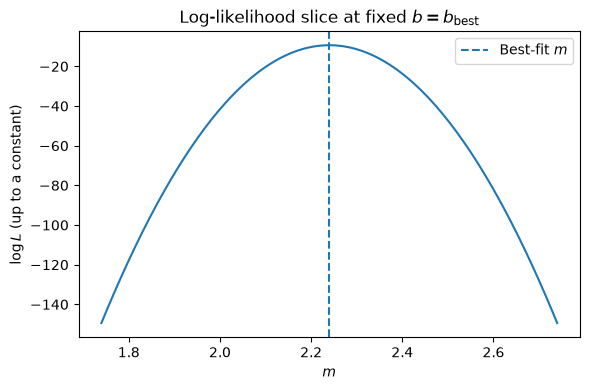

In [11]:
plt.figure(figsize=(6, 4))

plt.plot(m_values, logL_values)
plt.axvline(m, linestyle="--", label=r"Best-fit $m$")

plt.xlabel(r"$m$")
plt.ylabel(r"$\log L$ (up to a constant)")
plt.title(r"Log-likelihood slice at fixed $b=b_{\mathrm{best}}$")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Interpretation of the likelihood plot

The plot of $\log L$ as a function of $m$ shows a clear maximum near the best-fit slope.

This maximum corresponds to the most likely value of m under the Gaussian error model.

When m moves away from the best-fit value, the residuals become larger, the chi-square increases, and the log-likelihood decreases.

This is the first step toward Bayesian inference: instead of keeping only one best-fit value, we start thinking about which parameter values are more or less plausible.

This is, however, a one-dimensional slice of the likelihood with $b$ held fixed. Because $b$ and $m$ are correlated, its width should not be interpreted as the marginalized uncertainty on $m$.

## 8. Adding a uniform prior

Bayes' theorem gives

$$
p(\theta \mid D) \propto p(D \mid \theta)\,p(\theta),
$$

where $p(D \mid \theta)$ is the likelihood and $p(\theta)$ is the prior.

Taking the logarithm,

$$
\log p(\theta \mid D)
=
\log L(\theta)
+
\log p(\theta)
+
\text{constant}.
$$

For a uniform prior, $\log p(\theta)$ is constant inside the allowed parameter range and $-\infty$ outside it.

In [12]:
def log_prior(theta):
    b, m = theta

    if -100 < b < 200 and 0 < m < 5:
        return 0.0
    else:
        return -np.inf

In [13]:
def log_posterior(theta, x, y, sigma_y):
    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, x, y, sigma_y)

## 9. Maximizing the likelihood numerically

In [14]:
def neg_log_likelihood(theta, x, y, sigma_y):
    return -log_likelihood(theta, x, y, sigma_y)

theta0 = np.array([30.0,2.0])  #initial guess

result = minimize(neg_log_likelihood, theta0, args=(x_fit, y_fit, sigma_y_fit))
assert result.success, result.message

print("MLE [b, m]:", result.x)
print("Minimum negative log-likelihood:", result.fun)

MLE [b, m]: [34.04775498  2.23992067]
Minimum negative log-likelihood: 9.340384955621545


Since the prior is uniform and the best-fit parameters lie inside the allowed region, maximizing the posterior gives the same result as maximizing the likelihood. The prior mainly restricts the allowed parameter space.

In [15]:
def neg_log_posterior(theta, x, y, sigma_y):
    lp = log_posterior(theta, x, y, sigma_y)

    if not np.isfinite(lp):
        return 1e100

    return -lp

In [16]:
theta0 = np.array([30.0, 2.0])

bounds = [(-100, 200), (0, 5)]  # bounds for [b, m]

print("theta0:", neg_log_posterior(theta0, x_fit, y_fit, sigma_y_fit))
print("theta_best:", neg_log_posterior(theta_best, x_fit, y_fit, sigma_y_fit))

result_post = minimize(
    neg_log_posterior,
    theta0,
    args=(x_fit, y_fit, sigma_y_fit),
    bounds=bounds
)

print(result_post.x)
print(result_post.fun)

theta0: 48.09366129493828
theta_best: 9.340384955620404
[34.04769987  2.23992093]
9.340384955623716


## Conclusion

In this notebook, we rewrote the linear fit problem as a likelihood problem.

The key result is:

$$
\log L(\theta)
=
-\frac12 \chi^2(\theta)
+
\mathrm{constant}.
$$

This relation comes from assuming independent Gaussian uncertainties on the observed y-values.

The best-fit parameters maximize the log-likelihood because they minimize the chi-square.

The numerical maximum-likelihood and MAP estimates both recover $(b,m)\approx(34.05,2.2399)$, in agreement with the analytic weighted least-squares solution from Notebook 1.

This notebook prepares the next step: using MCMC to sample the posterior distribution,

$$
p(\theta|\mathrm{data}).
$$